# 01. Смотрим данные

## Зачем это делать в продукте

По условию внешние сервисы собирают объявления, цены и контакты продавцов. Модель должна помочь антибот-команде находить такой трафик. Но `score` сам по себе ничего не защищает. После него нужно действие: например, дополнительная проверка, ограничение частоты запросов или разбор спорных случаев

Промахнуться можно в обе стороны. Если пропустить бота, он продолжит собирать данные, и ущерб будет накапливаться. Без нижней границы recall можно было бы отмечать лишь несколько самых очевидных ботов и получить высокую precision, почти никого не остановив. Если принять человека за бота, можно помешать ему связаться с продавцом. Поэтому офлайн-метрика требует найти хотя бы 70% известных ботов, а среди порогов с такой полнотой выбирает лучшую точность. Это не доказательство, что любой пропущенный бот дороже любого задетого человека. Реальную цену ошибок ещё нужно выяснить у команды продукта

Оценка ставится в конце суточного окна. Это похоже на пакетный расчёт, но из размера учебного CSV нельзя делать вывод о нагрузке в проде. До выбора модели нужны ответы на три вопроса: как быстро должен появиться `score`, сколько кук придётся считать за час и что делать с высоким `score`? Пока считаем эти ограничения открытыми

### Как потом проверить пользу

Для A/B-теста сначала понадобится выбрать действие после высокого `score`. Сравнивать будем не просто число найденных ботов, а результат этого действия. Рабочая идея: стало ли меньше массовых просмотров и открытий контактов от подтверждённых сборщиков. При этом не должны просесть обращения обычных покупателей к продавцам.

Отдельно следим за жалобами и ошибочными проверками, задержкой ответа и нагрузкой на сервис. Recall в онлайне по одним логам не посчитать: понадобятся проверенные метки и для отмеченных, и для пропущенных кук. Единицу рандомизации тоже надо выбрать заранее. Одна кука может смениться, поэтому делить трафик только по `cookie_id` может быть ненадёжно.

Это пока схема, не готовый дизайн эксперимента. Порог, способ проверки и главную бизнес-метрику сможем зафиксировать, когда станет понятно, какое действие реально будут запускать

In [1]:
# Открой ноутбук из корня проекта или из папки notebooks.
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "data" / "train.csv").is_file():
    raise FileNotFoundError("Не найдена папка data. Открой ноутбук из проекта.")
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 125, "font.size": 10})
BLUE, ORANGE = "#3274A1", "#E1812C"
data_dir = Path("data")
train = pd.read_csv(data_dir / "train.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
test = pd.read_csv(data_dir / "test.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
events = pd.read_csv(data_dir / "events.csv.gz", parse_dates=["event_ts"])

for name, table in [("train", train), ("test", test), ("events", events)]:
    print(f"{name}: {len(table):,} строк, {table.shape[1]} колонок")
display(train.head(3), events.head(3))

train: 11,091 строк, 5 колонок
test: 4,909 строк, 4 колонок
events: 328,905 строк, 14 колонок


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0


## Куки и даты

В train 11 091 кука, в test 4 909. Проверим, нет ли повторов и пересечений, а заодно посмотрим, сколько ботов приходится на каждый день. Тест идёт позже обучения, и это важно для проверки моделей

In [2]:
print("Повторы cookie_id:", train.cookie_id.duplicated().sum(), "в train,", test.cookie_id.duplicated().sum(), "в test")
print("Общие куки:", len(set(train.cookie_id) & set(test.cookie_id)))
print("Пропуски в train/test:", train.isna().sum().sum(), test.isna().sum().sum())
print("Длительность окна:", (train.window_end_ts - train.window_start_ts).value_counts().to_dict())
print("Ботов:", int(train.target.sum()), "из", len(train), f"({train.target.mean():.1%})")

by_day = train.groupby("window_start_ts").target.agg(cookies="size", bots="sum", bot_share="mean")
test_by_day = test.groupby("window_start_ts").size().rename("test_cookies")
display(pd.concat([by_day, test_by_day], axis=1).round(3))

Повторы cookie_id: 0 в train, 0 в test
Общие куки: 0
Пропуски в train/test: 0 0
Длительность окна: {Timedelta('1 days 00:00:00'): 11091}
Ботов: 899 из 11091 (8.1%)


,cookies,bots,bot_share,test_cookies
window_start_ts,,,,
2026-04-06,772.0,68.0,0.088,NaN
2026-04-07,797.0,59.0,0.074,NaN
2026-04-08,834.0,70.0,0.084,NaN
2026-04-09,902.0,66.0,0.073,NaN
2026-04-10,912.0,82.0,0.090,NaN
2026-04-11,896.0,79.0,0.088,NaN
2026-04-12,817.0,67.0,0.082,NaN
2026-04-13,843.0,53.0,0.063,NaN
2026-04-14,826.0,70.0,0.085,NaN


На графике видно не только число кук по дням, но и то, как меняется доля ботов в train. Если в конце был бы резкий скачок, на временной валидации модель могла бы вести себя иначе

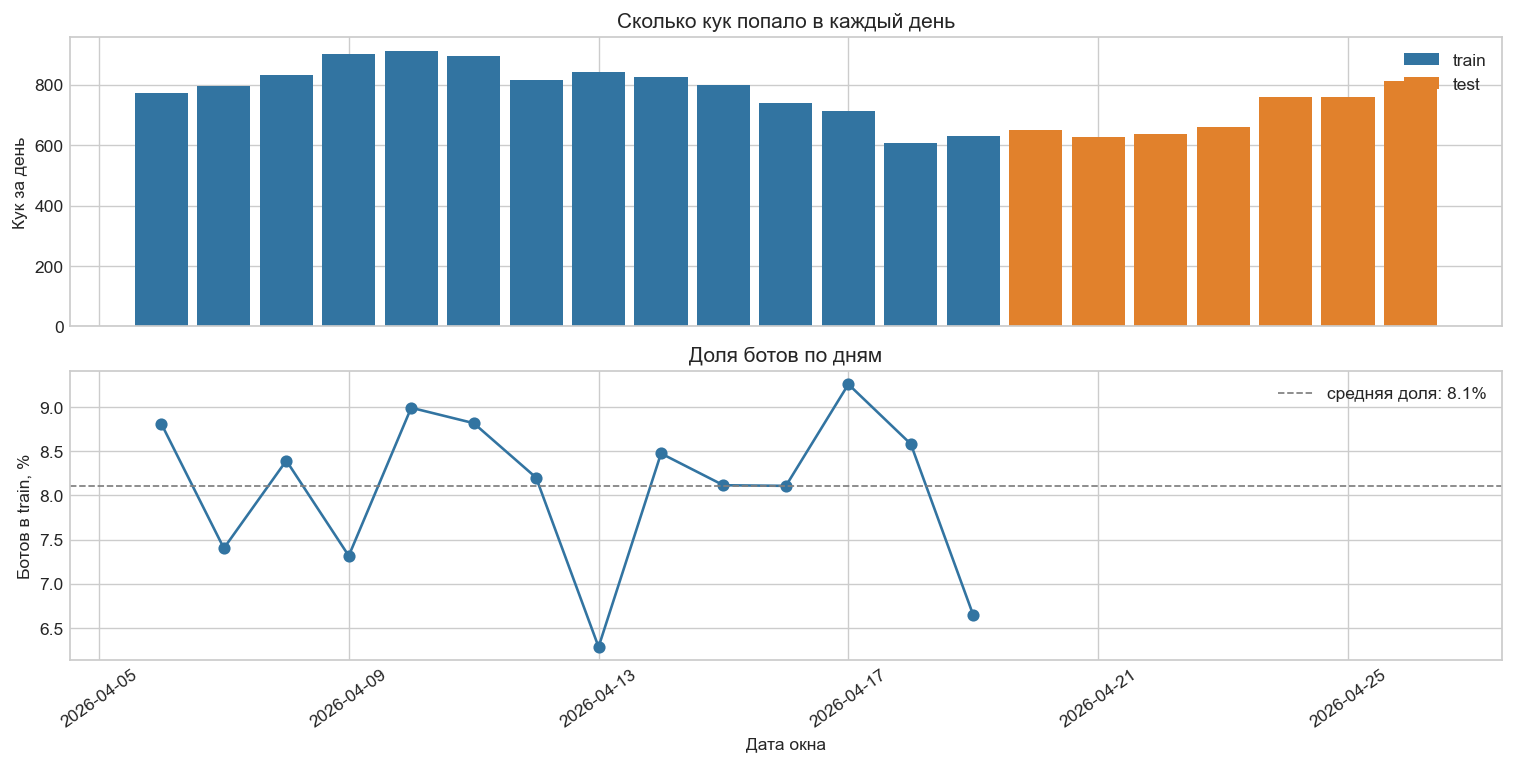

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, layout="constrained")
axes[0].bar(by_day.index, by_day.cookies, width=0.85, color=BLUE, label="train")
axes[0].bar(test_by_day.index, test_by_day, width=0.85, color=ORANGE, label="test")
axes[0].set(ylabel="Кук за день", title="Сколько кук попало в каждый день")
axes[0].legend(frameon=False)

axes[1].plot(by_day.index, by_day.bot_share * 100, marker="o", color=BLUE)
axes[1].axhline(train.target.mean() * 100, color="gray", linestyle="--", linewidth=1,
                label=f"средняя доля: {train.target.mean():.1%}")
axes[1].set(ylabel="Ботов в train, %", xlabel="Дата окна", title="Доля ботов по дням")
axes[1].legend(frameon=False)
axes[1].tick_params(axis="x", rotation=35)
plt.show()

Train занимает 6–19 апреля 2026 года, test начинается 20 апреля. Доля ботов по дням колеблется, но резкого скачка в конце train нет. Для валидации возьмём последние дни обучения, а не случайные строки

## Какие события нам вообще можно видеть

Для каждой куки в train или test указан день наблюдения: от `window_start_ts` до `window_end_ts`. Многие куки попадают на одну и ту же дату. Событие ровно на `window_end_ts` уже не входит в этот день

In [4]:
meta = pd.concat([train.assign(split="train"), test.assign(split="test")], ignore_index=True)
joined = events.merge(
    meta[["cookie_id", "window_start_ts", "window_end_ts", "cookie_created_at", "split"]],
    on="cookie_id", how="left", validate="many_to_one"
)

in_window = joined.event_ts.ge(joined.window_start_ts) & joined.event_ts.lt(joined.window_end_ts)
day_events = joined.loc[in_window].copy()
later_events = joined.loc[~in_window].copy()

print("Внутри окна по всем кукам:", len(day_events), "событий")
print("За окном по всем кукам:", len(later_events), "событий")
display(pd.crosstab(joined.split, in_window, rownames=["выборка"], colnames=["внутри окна"]))
print("Кук без событий в указанном окне:", len(set(meta.cookie_id) - set(day_events.cookie_id)))
print("Событий до создания куки:", int((day_events.event_ts < day_events.cookie_created_at).sum()))
print("Все события за окном произошли после его конца:", later_events.event_ts.ge(later_events.window_end_ts).all())

Внутри окна по всем кукам: 288126 событий
За окном по всем кукам: 40779 событий


внутри окна,False,True
выборка,,
test,0,89690
train,40779,198436


Кук без событий в указанном окне: 0
Событий до создания куки: 0
Все события за окном произошли после его конца: True


Вот пять первых кук из train для примера. У них может быть одна дата окна, но события мы считаем отдельно для каждой

In [5]:
inside_counts = day_events.groupby("cookie_id").size()
later_counts = later_events.groupby("cookie_id").size()
example = meta[["cookie_id", "window_start_ts", "window_end_ts"]].head(5).copy()
example["событий внутри"] = example.cookie_id.map(inside_counts).fillna(0).astype(int)
example["событий позже"] = example.cookie_id.map(later_counts).fillna(0).astype(int)
display(example)

,cookie_id,window_start_ts,window_end_ts,событий внутри,событий позже
0,ck_54a059eb7d3ea68b,2026-04-06,2026-04-07,7,3
1,ck_7e4de46eeab82974,2026-04-06,2026-04-07,41,0
2,ck_9320229ef6304522,2026-04-06,2026-04-07,36,7
3,ck_30ccd25bc1714ed9,2026-04-06,2026-04-07,21,1
4,ck_a77c5f05948cdeef,2026-04-06,2026-04-07,29,0


In [6]:
print("Что попало за окно:")
display(later_events.event_name.value_counts().rename("событий").to_frame())
print("Капча внутри окна:", int(day_events.event_name.eq("captcha_shown").sum()))

Что попало за окно:


,событий
event_name,
item_view,12731
search_results_view,10604
captcha_shown,7928
photo_swipe,3433
seller_page_view,1861
favorite_add,1753
contact_phone_show,1028
login,606
contact_chat_open,577


Капча внутри окна: 0


Здесь легко получить красивый, но нечестный результат: 40 779 событий train случились уже после нужных суток. Все 7 928 показов капчи тоже там. На момент прогноза их ещё нет, поэтому дальше работаем только с `day_events`

## Что лежит в истории

Файл не отсортирован по времени. Есть точные дубли и совпадения по времени внутри одной куки. Пока ничего не удаляем: сначала посмотрим на масштаб проблемы

In [7]:
print("Файл отсортирован по времени:", events.event_ts.is_monotonic_increasing)
print("Точных дублей:", events.duplicated().sum())
print("Точных дублей внутри окна:", day_events[events.columns].duplicated().sum())
print("Совпадений cookie_id + event_ts внутри окна:", day_events.duplicated(["cookie_id", "event_ts"]).sum())

counts = pd.crosstab(day_events.event_name, day_events.split)
display(counts.sort_values("train", ascending=False))
print("У каждого кода события одно название:", day_events.groupby("eid").event_name.nunique().eq(1).all())

Файл отсортирован по времени: False
Точных дублей: 4863


Точных дублей внутри окна: 4293
Совпадений cookie_id + event_ts внутри окна: 5806


split,test,train
event_name,,
item_view,33748,74338
search_results_view,28081,61717
photo_swipe,10133,22951
favorite_add,5259,12037
seller_page_view,4854,10688
contact_phone_show,3242,7046
login,1761,3900
contact_chat_open,1768,3780
contact_message_sent,844,1979


У каждого кода события одно название: True


Пропуски тоже не одинаковы по смыслу. У поиска есть запрос и номер страницы, но нет объявления. У просмотра объявления всё наоборот. Посмотрим это по типам событий, прежде чем что-то заполнять

In [8]:
fields = ["item_id", "item_category", "item_location", "seller_type",
          "search_query", "search_page", "pointer_x", "pointer_y"]
missing = day_events.groupby("event_name")[fields].apply(lambda x: x.isna().mean() * 100)
display(missing.round(0))

print("Платформы как записаны в файле:")
display(day_events.platform.value_counts().rename("событий").to_frame())
print("Разных User-Agent:", day_events.user_agent.nunique())

,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,
contact_chat_open,0.0,6.0,3.0,8.0,100.0,100.0,69.0,69.0
contact_message_sent,0.0,6.0,3.0,9.0,100.0,100.0,67.0,67.0
contact_phone_show,0.0,6.0,3.0,9.0,100.0,100.0,67.0,67.0
favorite_add,0.0,6.0,3.0,9.0,100.0,100.0,65.0,65.0
item_view,0.0,6.0,3.0,9.0,100.0,100.0,67.0,67.0
login,100.0,100.0,100.0,100.0,100.0,100.0,65.0,65.0
photo_swipe,0.0,6.0,3.0,9.0,100.0,100.0,66.0,66.0
search_results_view,100.0,6.0,3.0,100.0,0.0,0.0,67.0,67.0
seller_page_view,0.0,6.0,3.0,9.0,100.0,100.0,66.0,66.0


Платформы как записаны в файле:


,событий
platform,
desktop,40768
WEB,40330
Web,40269
web,39895
ANDROID,37597
Android,37357
android,37302
ios,3659
iphone,3656


Разных User-Agent: 148


`web`, `Web` и `WEB` обозначают одно и то же. Для признаков сведём написания к общему виду. А вот целую строку User-Agent лучше не превращать в категорию: версия браузера может поменяться, хотя поведение останется прежним

In [9]:
day_events["platform_group"] = day_events.platform.str.lower().replace({"desktop": "web", "iphone": "ios"})
print("После приведения платформ:")
display(pd.crosstab(day_events.platform_group, day_events.split, normalize="columns").round(3))

# Смотрим только на явный маркер в User-Agent, без попытки угадать бота по всей строке.
headless = day_events.user_agent.str.contains("HeadlessChrome", case=False, na=False)
headless_by_cookie = day_events.assign(headless=headless).groupby("cookie_id").headless.any()
ua_check = train[["cookie_id", "target"]].join(headless_by_cookie, on="cookie_id")
display(ua_check.groupby("headless").target.agg(cookies="size", bots="sum", bot_share="mean").round(3))

После приведения платформ:


split,test,train
platform_group,,
android,0.382,0.393
ios,0.046,0.053
web,0.571,0.554


,cookies,bots,bot_share
headless,,,
False,10805,824,0.076
True,286,75,0.262


`HeadlessChrome` встречается у ботов заметно чаще, но есть и у людей. Сам по себе этот маркер не решает задачу

## Как ведут себя куки

Начнём с понятных вещей: сколько было действий, сколько разных объявлений и запросов, как быстро шли события. Для интервала сначала сортируем историю каждой куки по времени. Если событие всего одно, интервала нет.

На графиках ниже линия показывает долю кук со значением не выше точки на оси X. Так видна вся форма распределения, а не только медиана

In [10]:
ordered = day_events.sort_values(["cookie_id", "event_ts"], kind="mergesort").copy()
ordered["gap_sec"] = ordered.groupby("cookie_id").event_ts.diff().dt.total_seconds()
ordered["has_pointer"] = ordered.pointer_x.notna() & ordered.pointer_y.notna()

g = ordered.groupby("cookie_id")
activity = g.agg(
    events=("eid", "size"),
    items=("item_id", "nunique"),
    categories=("item_category", "nunique"),
    locations=("item_location", "nunique"),
    queries=("search_query", "nunique"),
    first=("event_ts", "min"),
    last=("event_ts", "max"),
    median_gap_sec=("gap_sec", "median"),
    pointer_share=("has_pointer", "mean"),
)
activity["active_minutes"] = (activity["last"] - activity["first"]).dt.total_seconds() / 60
activity = activity.join(pd.crosstab(ordered.cookie_id, ordered.event_name).add_prefix("n_"))

profile = meta.merge(activity.reset_index(), on="cookie_id", how="left", validate="one_to_one")
profile["cookie_age_days"] = (profile.window_start_ts - profile.cookie_created_at).dt.total_seconds() / 86400
cols = ["events", "items", "categories", "locations", "queries", "median_gap_sec",
        "active_minutes", "pointer_share", "cookie_age_days", "n_search_results_view",
        "n_item_view", "n_photo_swipe", "n_favorite_add"]
labeled = profile[profile.split.eq("train")].copy()
labeled["group"] = labeled.target.map({0: "человек", 1: "бот"})
display(labeled.groupby("group")[cols].median().T.round(2))

group,бот,человек
events,20.00,12.00
items,10.00,6.00
categories,2.00,2.00
locations,8.00,5.00
queries,4.00,3.00
median_gap_sec,25.00,59.00
active_minutes,151.53,138.78
pointer_share,0.00,0.00
cookie_age_days,18.97,61.78
n_search_results_view,7.00,4.00


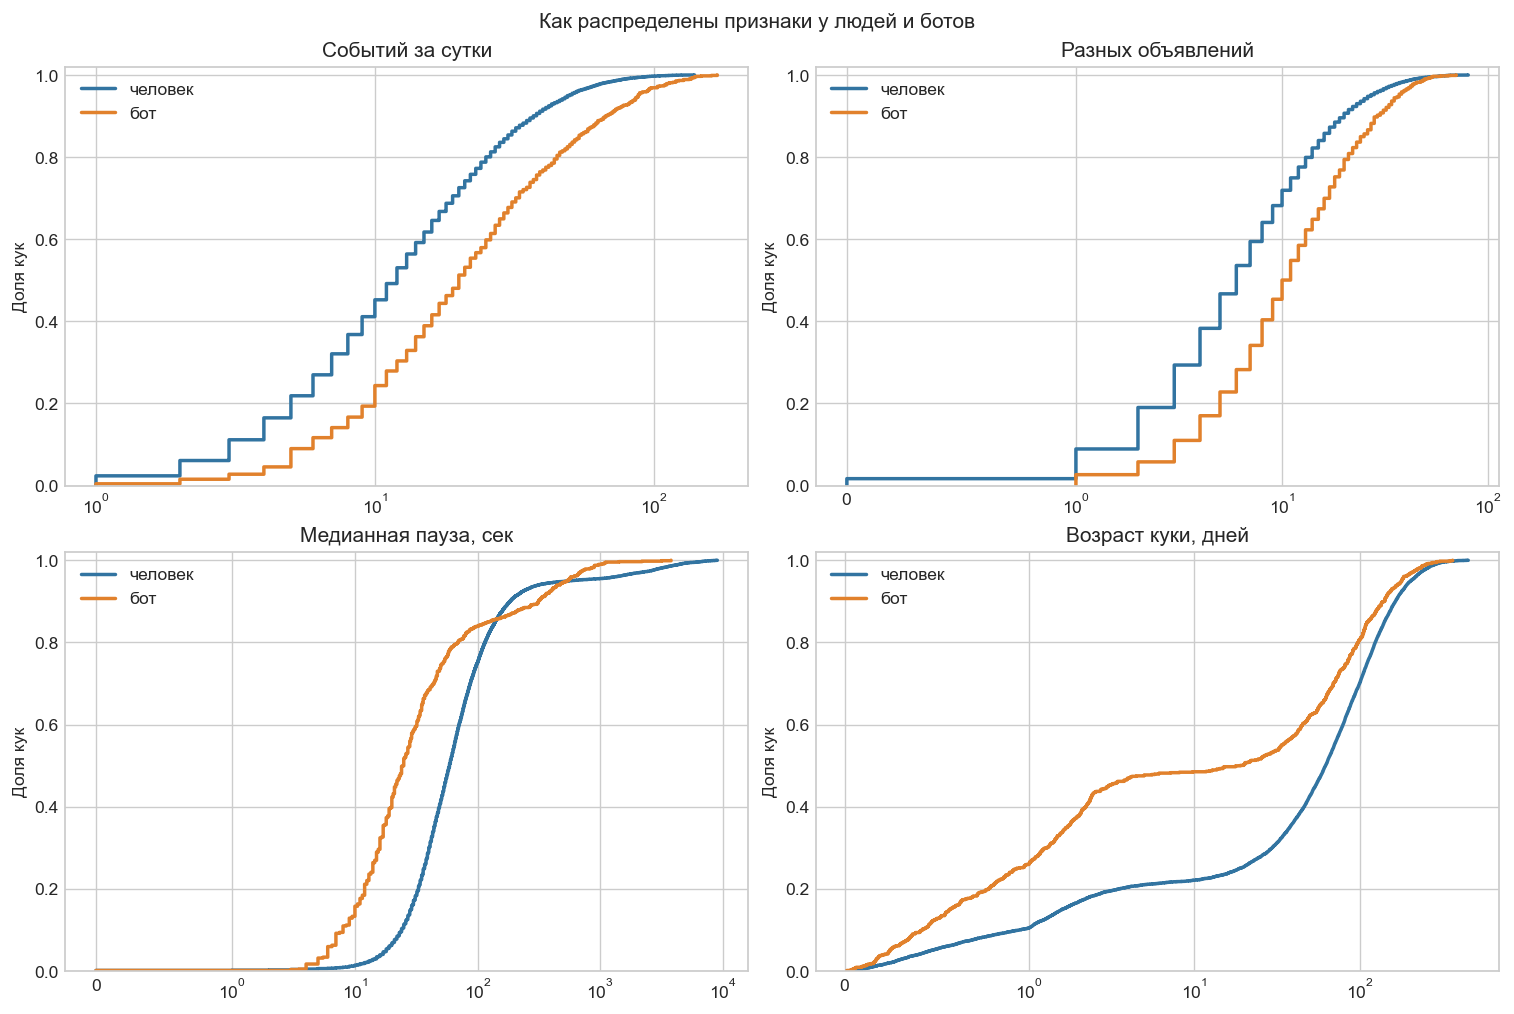

In [11]:
def draw_ecdf(ax, values, name, color):
    values = np.sort(values.dropna().to_numpy())
    y = np.arange(1, len(values) + 1) / len(values)
    ax.step(values, y, where="post", color=color, linewidth=2, label=name)

plots = [
    ("events", "Событий за сутки"),
    ("items", "Разных объявлений"),
    ("median_gap_sec", "Медианная пауза, сек"),
    ("cookie_age_days", "Возраст куки, дней"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
for ax, (column, title) in zip(axes.flat, plots):
    for target, name, color in [(0, "человек", BLUE), (1, "бот", ORANGE)]:
        draw_ecdf(ax, labeled.loc[labeled.target.eq(target), column], name, color)
    ax.set(title=title, ylabel="Доля кук")
    ax.set_xscale("symlog", linthresh=1)
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False)
fig.suptitle("Как распределены признаки у людей и ботов")
plt.show()

Логарифмическая шкала по X позволяет оставить на графике весь хвост, не превращая основную массу в узкую полоску. Но график не заменяет числа: отдельно посмотрим медиану, 90-й и 99-й процентили, максимум, долю нулей и пропусков.

У интервалов между событиями особенно длинный хвост: максимум измеряется тысячами секунд. У кук с одним событием интервал вообще не определён, и это не то же самое, что ноль

медиана    p90     p99  максимум  нулей, %  \
признак         класс                                                 
events          бот         20.0   67.2   134.0     169.0       0.0   
                человек     12.0   37.0    79.0     140.0       0.0   
items           бот         10.0   29.0    49.0      70.0       0.0   
                человек      6.0   20.0    44.0      80.0       1.7   
median_gap_sec  бот         25.0  313.6   973.4    3777.5       0.1   
                человек     59.0  183.1  4419.8    9005.0       0.1   
cookie_age_days бот         19.0  139.1   249.2     361.8       0.0   
                человек     61.8  163.6   283.3     449.3       0.0   

                         пропусков, %  
признак         класс                  
events          бот               0.0  
                человек           0.0  
items           бот               0.0  
                человек           0.0  
median_gap_sec  бот               0.4  
                человек           2.4  
cookie_age_days бот               0.0  
                человек           0.0

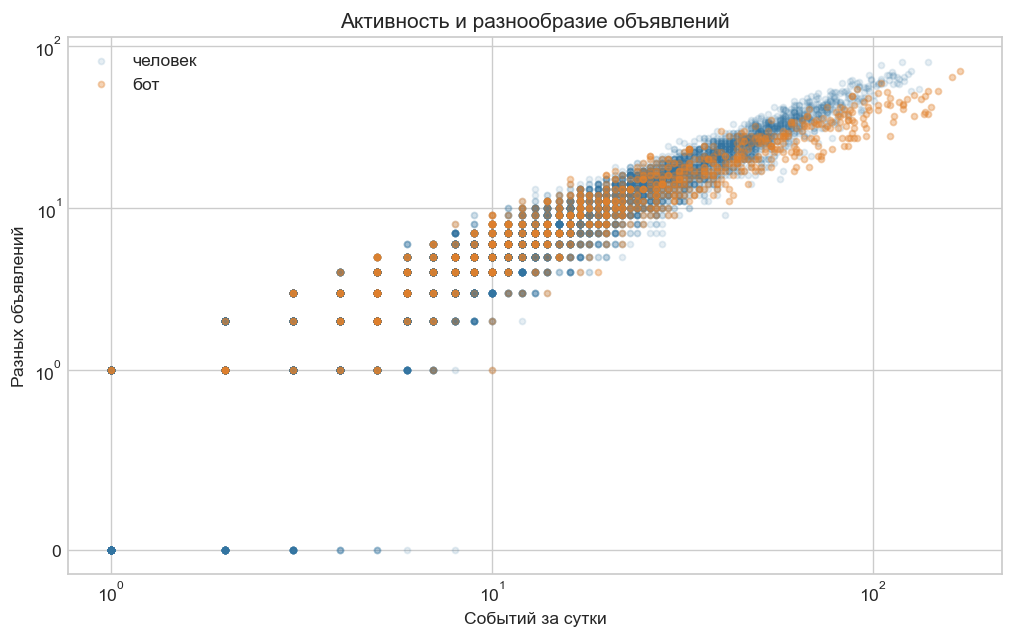

In [12]:
tail_rows = []
for column in ["events", "items", "median_gap_sec", "cookie_age_days"]:
    for name, part in labeled.groupby("group"):
        values = part[column]
        tail_rows.append({
            "признак": column, "класс": name,
            "медиана": values.median(), "p90": values.quantile(.90),
            "p99": values.quantile(.99), "максимум": values.max(),
            "нулей, %": values.eq(0).mean() * 100,
            "пропусков, %": values.isna().mean() * 100,
        })
display(pd.DataFrame(tail_rows).round(1).set_index(["признак", "класс"]))

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
for target, name, color, alpha in [(0, "человек", BLUE, .12), (1, "бот", ORANGE, .35)]:
    part = labeled[labeled.target.eq(target)]
    ax.scatter(part["events"], part["items"], s=12, alpha=alpha, color=color, label=name)
ax.set(xlabel="Событий за сутки", ylabel="Разных объявлений",
       title="Активность и разнообразие объявлений")
ax.set_xscale("symlog", linthresh=1)
ax.set_yscale("symlog", linthresh=1)
ax.legend(frameon=False)
plt.show()

Для линейной модели важна форма распределения. Например, число событий сильно скошено вправо: большинство кук малоактивны, но есть длинный хвост. Ниже одно и то же распределение до и после `log1p`. Пока ничего не меняем в данных, просто смотрим, стоит ли попробовать такое преобразование позже

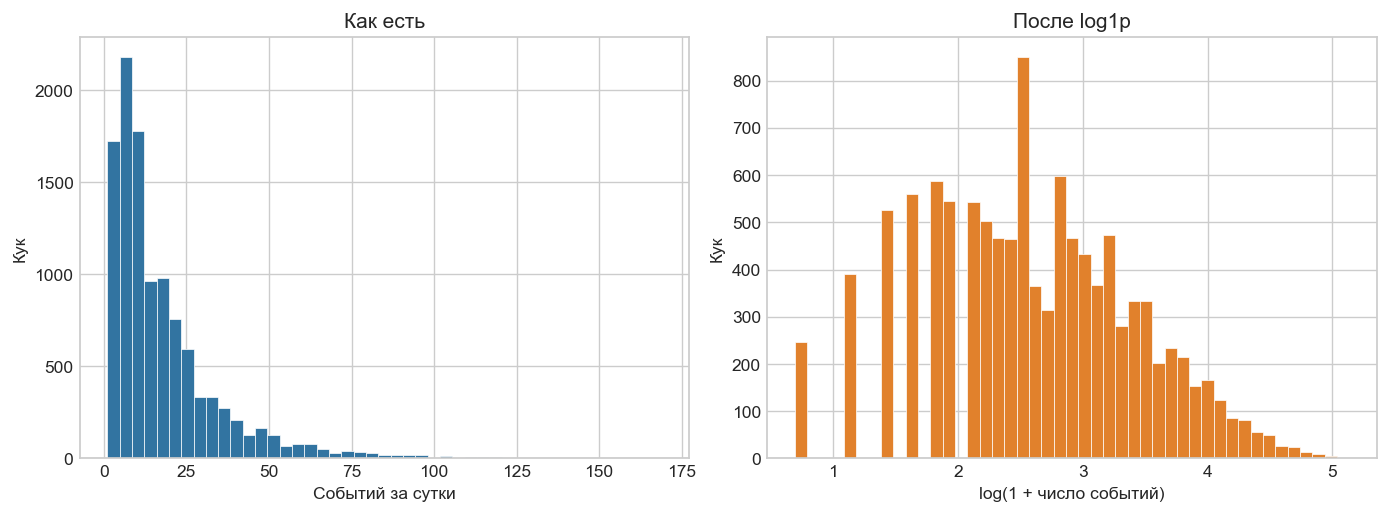

Асимметрия: до 2.39, после 0.03


In [13]:
raw = labeled.events
logged = np.log1p(raw)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].hist(raw, bins=45, color=BLUE, edgecolor="white", linewidth=.4)
axes[0].set(title="Как есть", xlabel="Событий за сутки", ylabel="Кук")
axes[1].hist(logged, bins=45, color=ORANGE, edgecolor="white", linewidth=.4)
axes[1].set(title="После log1p", xlabel="log(1 + число событий)", ylabel="Кук")
plt.show()
print(f"Асимметрия: до {raw.skew():.2f}, после {logged.skew():.2f}")

Ещё один вопрос для линейных моделей: не описывают ли несколько колонок почти одно и то же. Смотрим корреляцию счётчиков после `log1p`. Если она высокая, коэффициенты будет сложнее читать, а регуляризация станет особенно полезной.

Особенно тесно связаны общее число событий и число разных объявлений. Если оставить оба признака, регуляризация поможет не раздувать коэффициенты

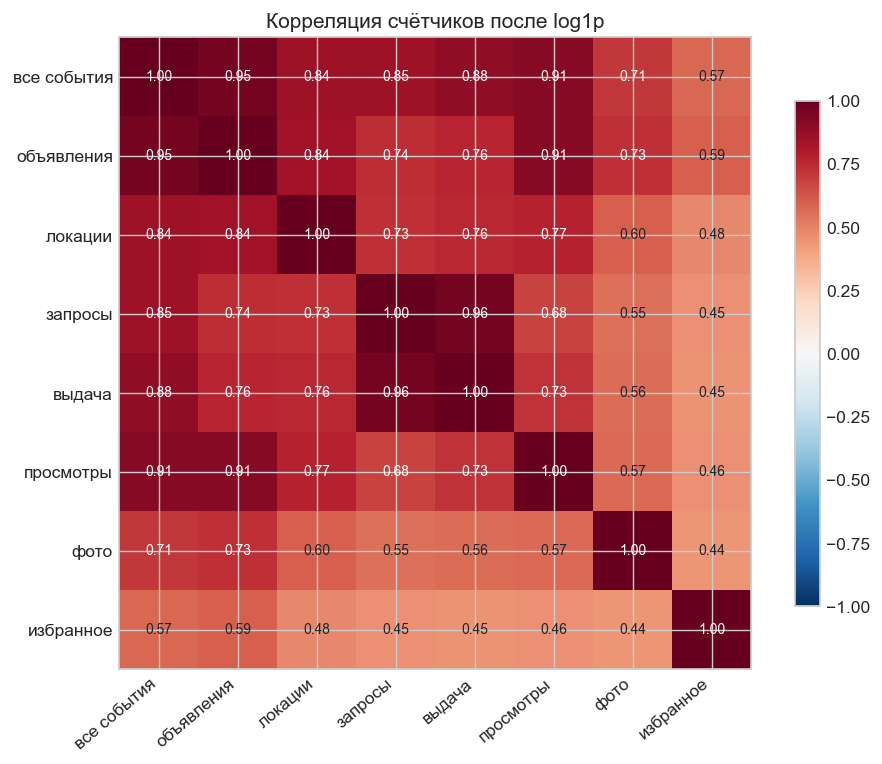

In [14]:
count_cols = ["events", "items", "locations", "queries", "n_search_results_view",
              "n_item_view", "n_photo_swipe", "n_favorite_add"]
corr = np.log1p(labeled[count_cols]).corr()
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axis_labels = ["все события", "объявления", "локации", "запросы", "выдача",
               "просмотры", "фото", "избранное"]
ax.set_xticks(range(len(count_cols)), axis_labels, rotation=40, ha="right")
ax.set_yticks(range(len(count_cols)), axis_labels)
for row in range(len(count_cols)):
    for col in range(len(count_cols)):
        value = corr.iloc[row, col]
        ink = "white" if value >= .65 else "#20242a"
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", fontsize=8, color=ink)
ax.set_title("Корреляция счётчиков после log1p")
fig.colorbar(image, ax=ax, shrink=.8)
plt.show()

У ботов медиана 20 событий против 12 у людей. Паузы короче: 25 секунд против 59. Но на графиках видно большое пересечение, так что один такой показатель вряд ли хватит. Боты также чаще открывают выдачу и объявления; люди чаще добавляют объявления в избранное

## Не уехал ли test от train

Метки test мы не знаем. Зато можно сравнить обычные признаки и состав событий. Сильный сдвиг тут подсказал бы, что результат валидации может плохо перенестись на тест

In [15]:
check = ["events", "items", "categories", "locations", "queries",
         "median_gap_sec", "active_minutes", "pointer_share", "cookie_age_days"]
display(profile.groupby("split")[check].median().T.round(2))
display(profile.groupby("split").events.quantile([0.1, 0.5, 0.9, 0.99]).unstack().round(1))
display(pd.crosstab(day_events.event_name, day_events.split, normalize="columns").round(3))

split,test,train
events,12.00,12.00
items,6.00,6.00
categories,2.00,2.00
locations,5.00,5.00
queries,3.00,3.00
median_gap_sec,55.00,56.00
active_minutes,139.37,140.17
pointer_share,0.00,0.00
cookie_age_days,58.63,59.76


,0.10,0.50,0.90,0.99
split,,,,
test,3.0,12.0,40.0,92.0
train,3.0,12.0,40.0,87.0


split,test,train
event_name,,
contact_chat_open,0.020,0.019
contact_message_sent,0.009,0.010
contact_phone_show,0.036,0.036
favorite_add,0.059,0.061
item_view,0.376,0.375
login,0.020,0.020
photo_swipe,0.113,0.116
search_results_view,0.313,0.311
seller_page_view,0.054,0.054


Медианы за весь период похожи. На всякий случай посмотрим их по датам: среднее за две недели могло бы скрыть сдвиг прямо перед тестом

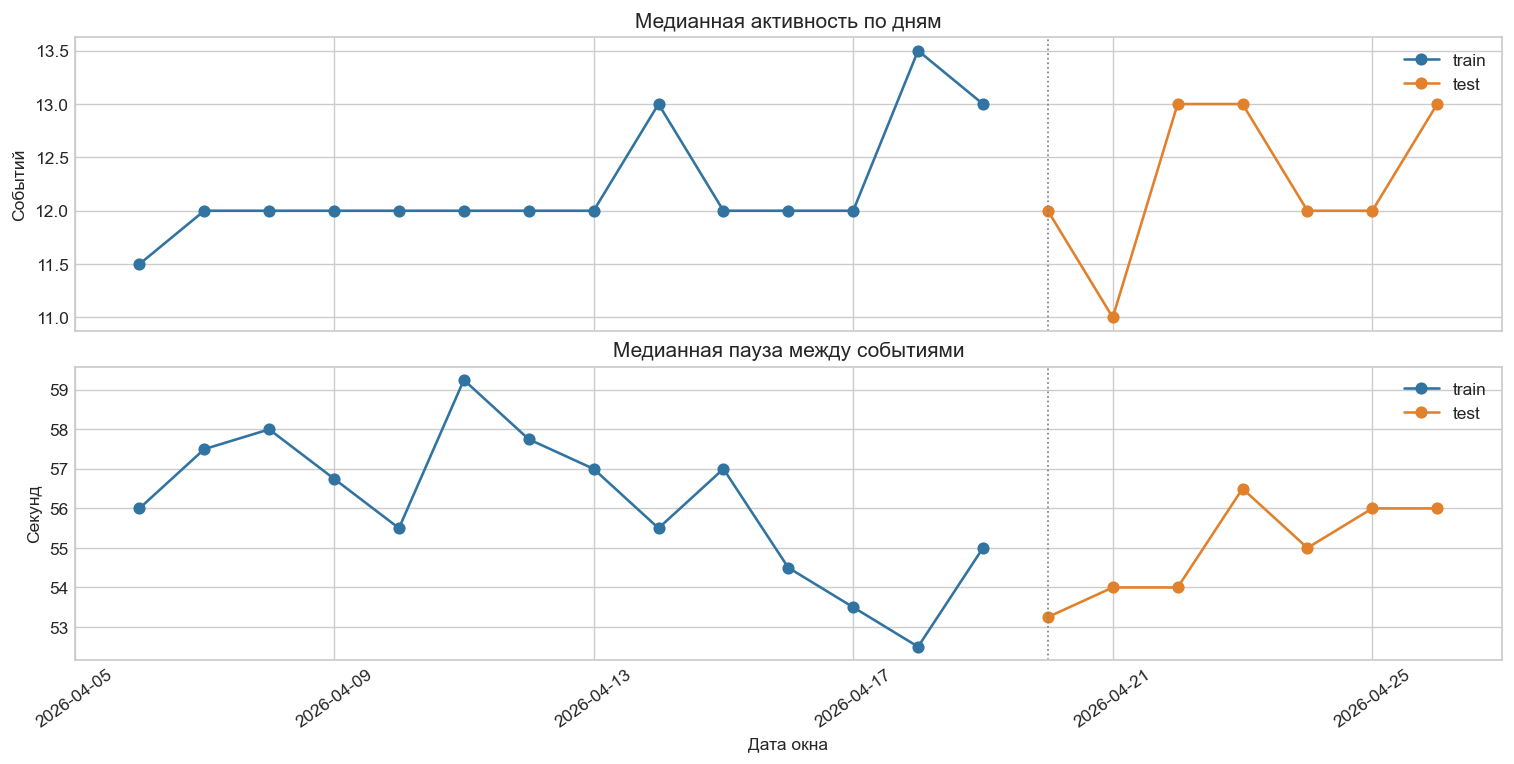

In [16]:
daily = profile.groupby(["split", "window_start_ts"])[["events", "median_gap_sec"]].median()
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, layout="constrained")
for split, color in [("train", BLUE), ("test", ORANGE)]:
    part = daily.loc[split]
    axes[0].plot(part.index, part.events, marker="o", color=color, label=split)
    axes[1].plot(part.index, part.median_gap_sec, marker="o", color=color, label=split)
for ax in axes:
    ax.axvline(test.window_start_ts.min(), color="gray", linestyle=":", linewidth=1)
    ax.legend(frameon=False)
axes[0].set(ylabel="Событий", title="Медианная активность по дням")
axes[1].set(ylabel="Секунд", xlabel="Дата окна", title="Медианная пауза между событиями")
axes[1].tick_params(axis="x", rotation=35)
plt.show()

По основным признакам train и test похожи. Медиана числа событий в обоих равна 12, а доли типов событий почти не меняются. Небольшие дневные колебания есть, поэтому валидацию всё равно делаем по времени.

## Что берём дальше

- Для бейзлайна хватит нескольких понятных признаков из разрешённого окна: объём действий, разнообразие объявлений и запросов, паузы, возраст куки.
- Для линейной модели стоит проверить `log1p`, масштабирование и индикатор отсутствующего интервала у кук с одним событием. Все преобразования будем подбирать только на обучающей части.
- Счётчики местами сильно связаны друг с другом. Это важно при чтении коэффициентов и выборе регуляризации.
- Позже сравним качество моделей с временем расчёта признаков и предсказаний. По этим 16 000 кукам нельзя угадать реальные требования к нагрузке.
- Офлайн-качество посчитаем через `precision_at_recall` из `utils/metric.py`. Продуктовый эффект потребует отдельной проверки после выбора действия по `score`